In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# want to compare SBS_D+ samples to the MSI and POLD1 samples

In [3]:
si = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_tumour_specific_Manuscript_v2.csv',index_col=0)

si_country =  pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_core_data_Manuscript_v2.csv',index_col=0)

si_marcos = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata_OG/CRC_metadata_2023SEP14.csv',index_col = 0)




pold1 = pd.read_csv('/Users/kazachkova/Downloads/POLD1.csv',index_col=0,skiprows=[0,1])

pold1_samples = ['PD47115a','PD54896a','PD55467a']

In [4]:
# actually should just be able to use the activities from the MSI to figure out which ones are MSI

msi_matrix = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/mutographs_SBS288_extraction_MSI/Samples.txt',
             index_col=0)

# mss_matrix =  pd.read_table('/Users/kazachkova/Documents/tscc/mutographs_SBS288_extraction/Samples.txt',
#              index_col=0)

mss_matrix =  pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/SBS_MSS_matrices/CRC_Manuscript_Subset_v2.SBS288.all',
             index_col=0)

In [5]:
# and need to know which ones are SBS288D positive 

acts_MSA = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/pruned_attribution_CRC_Manuscript_denovo_SBS288_abs_mutations.csv',index_col=0)

acts_MSA['tumorsite_group'] = si_marcos.loc[:,'tumorsite_group']

In [6]:
sbs_all = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/CRC_Manuscript_v1.SBS288.all',
             index_col=0)

# and we also need the indels 
import pandas as pd
indels_all = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/CRC_Manuscript_v1.ID83.all',
             index_col=0)



indels_mss = indels_all.loc[:,mss_matrix.columns]
indels_msi = indels_all.loc[:,msi_matrix.columns]

In [7]:
summary_stats = pd.DataFrame(index = sbs_all.columns,
                            columns = ['total_SBS','total_IDs','status'])


summary_stats.loc[:,'total_SBS' ] = sbs_all.sum()
summary_stats.loc[:,'total_IDs' ] = indels_all.sum()

summary_stats.loc[msi_matrix.columns,'status'] = 'MSI'
summary_stats.loc[pold1_samples,'status'] = 'POLD1'

summary_stats.loc[acts_MSA[acts_MSA.loc[:,'SBS288D']>0].index,'status'] = 'MSS_SBS288D+'

summary_stats.loc[acts_MSA[acts_MSA.loc[:,'SBS288D']==0].index,'status'] = 'MSS_SBS288D-'


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75639/1350622048.py:5: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  summary_stats.loc[:,'total_SBS' ] = sbs_all.sum()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75639/1350622048.py:6: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  summary_stats.loc[:,'total_IDs' ] = indels_all.sum()


In [9]:
si_marcos_full = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/Metadata_TMB_Signatures_SBS_ID_DBS_CN_SV_Drivers_2024AUG21.tsv',
             index_col=0)


summary_stats['PGA'] = si_marcos_full.loc[:,'PGA']

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75639/2853703390.py:7: FutureWarning: The default value of regex will change from True to False in a future version.
  summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\+','MSS\nSBS_D+\n(n=428)')
/Users/kazachkova/miniconda3/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 11.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/kazachkova/miniconda3/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 18.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


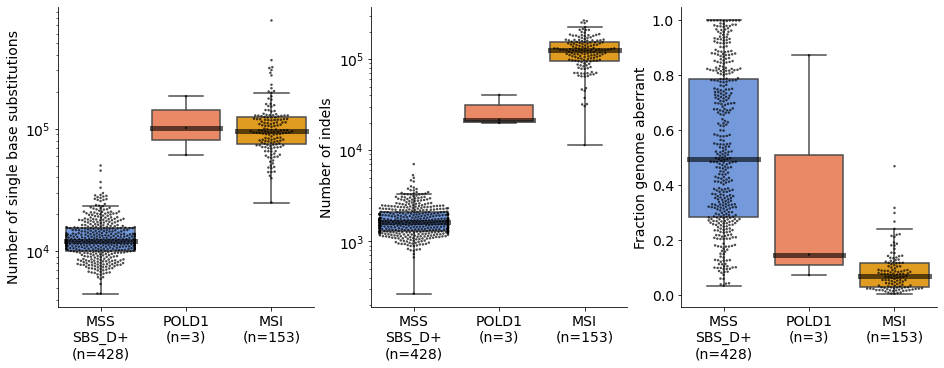

In [10]:
fig,ax = plt.subplots(1,3,figsize=(13,5),constrained_layout=True)

summary_stats_ = summary_stats.copy()
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('_','\n')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('SBS288D','SBS_D')

summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\+','MSS\nSBS_D+\n(n=428)')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('POLD1','POLD1\n(n=3)')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSI','MSI\n(n=153)')



                                                                           
ax[0].set_yscale('log')
sns.boxplot(data = summary_stats_,
            x='status',
            y='total_SBS',
           order=['MSS\nSBS_D+\n(n=428)','POLD1\n(n=3)','MSI\n(n=153)'],
           palette=['cornflowerblue','coral','orange'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[0],
           showfliers=False)


sns.swarmplot(data = summary_stats_,
            x='status',
            y='total_SBS',
           order=['MSS\nSBS_D+\n(n=428)','POLD1\n(n=3)','MSI\n(n=153)'],
           palette=['black','black','black'],ax=ax[0],alpha=.7,size=2.5)
           #color='black',alpha=.2)


ax[0].set_xlabel('')
ax[0].set_ylabel('Number of single base substitutions')


################################################

ax[1].set_yscale('log')
sns.boxplot(data = summary_stats_,
            x='status',
            y='total_IDs',
           order=['MSS\nSBS_D+\n(n=428)','POLD1\n(n=3)','MSI\n(n=153)'],
           palette=['cornflowerblue','coral','orange'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[1],
           showfliers=False)


sns.swarmplot(data = summary_stats_,
            x='status',
            y='total_IDs',
           order=['MSS\nSBS_D+\n(n=428)','POLD1\n(n=3)','MSI\n(n=153)'],
           palette=['black','black','black'],ax=ax[1],alpha=.7,size=2.5)
           #color='black',alpha=.2)


ax[1].set_xlabel('')
ax[1].set_ylabel('Number of indels')


################################################

sns.boxplot(data = summary_stats_,
            x='status',
            y='PGA',
           order=['MSS\nSBS_D+\n(n=428)','POLD1\n(n=3)','MSI\n(n=153)'],
           palette=['cornflowerblue','coral','orange'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[2],
           showfliers=False)


sns.swarmplot(data = summary_stats_,
            x='status',
            y='PGA',
           order=['MSS\nSBS_D+\n(n=428)','POLD1\n(n=3)','MSI\n(n=153)'],
           palette=['black','black','black'],ax=ax[2],alpha=.7,size=2.5)
           #color='black',alpha=.2)

ax[2].set_xlabel('')
ax[2].set_ylabel('Fraction genome aberrant')



for i in range(0,3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

    for item in ([ ax[i].title,  ax[i].xaxis.label,  ax[i].yaxis.label] +
                  ax[i].get_xticklabels() +  ax[i].get_yticklabels()):
        item.set_fontsize(14)
        
# plt.savefig('plots_for_paper/comparing_SBSD_POLD1_MSI.png',dpi=300)
